In [78]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 


In [79]:
df=pd.read_csv('SIMPLE_DATA.csv')
df.head()

,Height,Weight
0,145,42
1,148,44
2,150,45
3,152,47
4,154,49


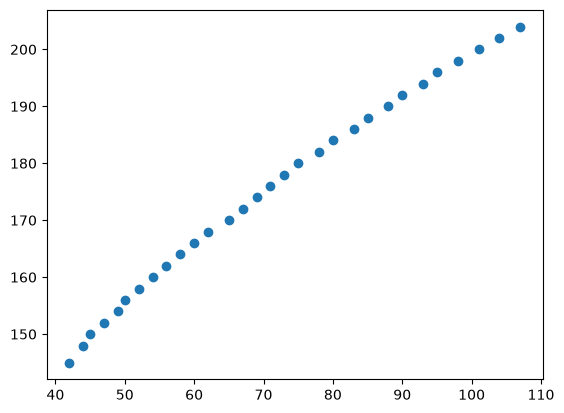

In [80]:
plt.scatter(df['Weight'], df['Height'])


In [81]:
df.corr()

,Height,Weight
Height,1.000000,0.996701
Weight,0.996701,1.000000


In [82]:
X=df[['Weight']]
Y=df['Height']

In [83]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y, test_size=0.25, random_state=42)

In [84]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [85]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train, Y_train)
print(regression.coef_)
print(regression.intercept_)



[17.13024272]
171.77272727272728


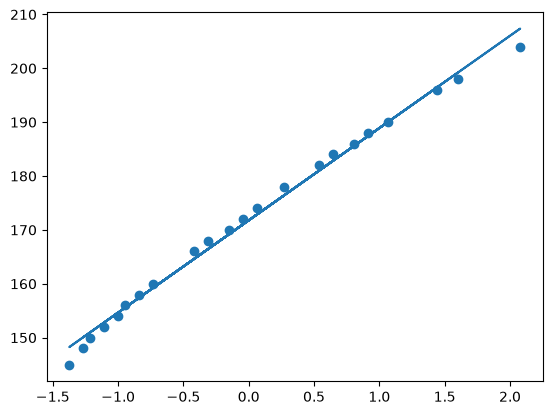

In [86]:
plt.scatter(X_train, Y_train)
plt.plot(X_train, regression.predict(X_train))


In [87]:
y_pred=regression.predict(X_test)

In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mse=mean_squared_error(Y_test, y_pred)
mae=mean_absolute_error(Y_test, y_pred)
rmse=np.sqrt(mse)
print(mae)
print(mse)
print(rmse)


1.3267183977350179
2.304973735877117
1.5182139954160339


In [89]:
from sklearn.metrics import r2_score
score=r2_score(Y_test, y_pred)
1-(1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)

0.9874008268219504

In [90]:
import statsmodels.api as sm 
model=sm.OLS(Y_train, X_train).fit()
prediction=model.predict(X_test)
print(prediction)
print(model.summary())

[ 30.14118244   2.85286912  20.13546756   6.4913109  -10.79128754
  -8.97206665  32.87001377  22.86429889]
                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.010
Model:                            OLS   Adj. R-squared (uncentered):             -0.037
Method:                 Least Squares   F-statistic:                             0.2088
Date:                Fri, 03 Jul 2026   Prob (F-statistic):                       0.652
Time:                        16:41:25   Log-Likelihood:                         -144.43
No. Observations:                  22   AIC:                                      290.9
Df Residuals:                      21   BIC:                                      292.0
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
             

In [91]:
regression.predict([[104]])

array([1953.31797001])

In [96]:
new_height = scaler.transform([[107]])
prediction = regression.predict(new_height)
print(prediction)

[207.37157238]


c:\Users\DELL\Desktop\python practice set\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [93]:
print(regression.coef_)
print(regression.intercept_)
print(X_train.min(), X_train.max())
print(X_train[:5])

[17.13024272]
171.77272727272728
-1.3733508710172893 2.0781284709066545
[[-0.15205818]
 [-1.37335087]
 [-1.0016531 ]
 [ 0.27273928]
 [-0.94855341]]
